In [41]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.DEBUG, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import sdata
import uuid
import matplotlib.pyplot as plt
modulepath = os.getcwd()
modulepath

07:00:22 DEBUG:Loaded backend module://ipykernel.pylab.backend_inline version unknown.


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Autosave disabled


'/home/ingolf.lepenies/projects/sdata/ipynb'

In [42]:
workpath = os.path.abspath(os.path.join("..", "data", "numisheet_2020"))
workpath
os.listdir(workpath)

['analyze-NS-rawdata.csv',
 'numisheet_2020_tensioncompression.csv',
 'numisheet_2020_tensioncompression.xlsx',
 'README.md',
 'analyze-NS-rawdata-attributes.csv',
 'numisheet_2020_tensioncompression.json']

In [43]:
df_exp = pd.read_csv(os.path.join(workpath, "analyze-NS-rawdata.csv"))
df_exp.drop_duplicates(inplace=True)
df_exp

,Time,Displacement,Force,Estress,Estrain,Tstress,Tstrain,Specimen,Material,Geometry,...,dedt,IntendedRate,StrainA,StrainfG,eyyA,eyyfgA,Path,ASPID,NumisheetID,dedtnomlabel
0,0.0000,-39.8488,2.0,0.106611,0.000000e+00,0.106611,0.000000e+00,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,0.000000e+00,0.000000e+00,-0.000008,-1.490744e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
1,0.1998,-39.8488,0.0,0.000000,-2.387196e-06,0.000000,-2.387199e-06,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,-2.387196e-06,-1.660862e-05,-0.000018,-3.191302e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
2,0.3998,-39.8408,0.5,0.026653,-9.703206e-06,0.026652,-9.703253e-06,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,-9.703206e-06,-1.199776e-05,-0.000023,-2.356464e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
3,0.5997,-39.8464,0.0,0.000000,7.457243e-06,0.000000,7.457216e-06,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,7.457243e-06,1.634256e-05,0.000002,8.166672e-07,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
4,0.7998,-39.8544,1.5,0.079958,-6.686905e-07,0.079958,-6.686907e-07,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,-6.686905e-07,6.182839e-07,-0.000009,-1.094360e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27775,926.9503,-39.6728,20554.5,1080.533708,1.523150e-01,1245.115188,1.417730e-01,S200123-ERR-076,DP1180,A36R19W18,...,NaN,0.00025,1.523150e-01,1.809150e-01,0.153237,1.838798e-01,TCT,NaN,NaN,0.00025 mm/mm/s
27776,927.9503,-39.6752,20452.5,1075.171649,1.527800e-01,1239.436373,1.421764e-01,S200123-ERR-076,DP1180,A36R19W18,...,NaN,0.00025,1.527800e-01,1.817564e-01,0.153766,1.848752e-01,TCT,NaN,NaN,0.00025 mm/mm/s
27777,928.9504,-39.6544,20372.5,1070.966113,1.532584e-01,1235.100708,1.425914e-01,S200123-ERR-076,DP1180,A36R19W18,...,NaN,0.00025,1.532584e-01,1.825970e-01,0.154237,1.858361e-01,TCT,NaN,NaN,0.00025 mm/mm/s
27778,929.9504,-39.6488,20254.0,1064.736662,1.537417e-01,1228.431038,1.430103e-01,S200123-ERR-076,DP1180,A36R19W18,...,NaN,0.00025,1.537417e-01,1.834580e-01,0.154888,1.871302e-01,TCT,NaN,NaN,0.00025 mm/mm/s


In [44]:
data = sdata.Data.from_json(filepath=os.path.join(workpath, "numisheet_2020_tensioncompression.json"))
data.describe()

,0
metadata,25
table_rows,27780
table_columns,21
description,76


In [45]:
df_exp = data.df
df_exp.head()

,Time,Displacement,Force,Estress,Estrain,Tstress,Tstrain,Specimen,Material,Geometry,...,dedt,IntendedRate,StrainA,StrainfG,eyyA,eyyfgA,Path,ASPID,NumisheetID,dedtnomlabel
index,,,,,,,,,,,,,,,,,,,,,
0,0.0000,-39.8488,2.0,0.106611,0.000000e+00,0.106611,0.000000e+00,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,0.000000e+00,0.000000e+00,-0.000008,-1.490744e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
1,0.1998,-39.8488,0.0,0.000000,-2.387196e-06,0.000000,-2.387199e-06,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,-2.387196e-06,-1.660862e-05,-0.000018,-3.191302e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
2,0.3998,-39.8408,0.5,0.026653,-9.703206e-06,0.026652,-9.703253e-06,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,-9.703206e-06,-1.199776e-05,-0.000023,-2.356464e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
3,0.5997,-39.8464,0.0,0.000000,7.457243e-06,0.000000,7.457216e-06,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,7.457243e-06,1.634256e-05,0.000002,8.166672e-07,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s
4,0.7998,-39.8544,1.5,0.079958,-6.686905e-07,0.079958,-6.686907e-07,S190918-ERR-071,DP1180,A36R19W18,...,NaN,0.00025,-6.686905e-07,6.182839e-07,-0.000009,-1.094360e-05,TCT,LOT#19: 1.00x CR825Y1180T-DP-UNCOATED-U,NaN,0.00025 mm/mm/s


In [46]:
df_exp.columns

Index(['Time', 'Displacement', 'Force', 'Estress', 'Estrain', 'Tstress',
       'Tstrain', 'Specimen', 'Material', 'Geometry', 'Experiment', 'dedt',
       'IntendedRate', 'StrainA', 'StrainfG', 'eyyA', 'eyyfgA', 'Path',
       'ASPID', 'NumisheetID', 'dedtnomlabel'],
      dtype='object')

In [47]:
df_exp["Experiment"].unique()

array(['E190926-WEL-002', 'E191001-WEL-002', 'E191002-WEL-001',
       'E191002-WEL-002', 'E191015-WEL-001', 'E191120-WEL-001',
       'E191120-WEL-002', 'E191121-WEL-001', 'E191121-WEL-002',
       'E191218-WEL-001', 'E191219-WEL-002', 'E191219-WEL-001',
       'E200128-WEL-001', 'E200131-WEL-001', 'E200131-WEL-002',
       'E200131-WEL-003', 'E200131-WEL-004'], dtype=object)

In [48]:
df_exp["Material"].unique()

array(['DP1180', 'DP980', '6xxxT81', '6xxxT4'], dtype=object)

In [49]:
#for matname, df_mat in df_exp.groupby("Material"):
for expname, df in df_exp.groupby("Experiment"):
    print(matname)
    print(df.head(2))
    print(df.tail(2))

DP980
         Time  Displacement  Force   Estress   Estrain   Tstress   Tstrain  \
index                                                                        
0      0.0000      -39.8488    2.0  0.106611  0.000000  0.106611  0.000000   
1      0.1998      -39.8488    0.0  0.000000 -0.000002  0.000000 -0.000002   

              Specimen Material   Geometry  ... dedt  IntendedRate   StrainA  \
index                                       ...                                
0      S190918-ERR-071   DP1180  A36R19W18  ...  NaN       0.00025  0.000000   
1      S190918-ERR-071   DP1180  A36R19W18  ...  NaN       0.00025 -0.000002   

       StrainfG      eyyA    eyyfgA  Path  \
index                                       
0      0.000000 -0.000008 -0.000015   TCT   
1     -0.000017 -0.000018 -0.000032   TCT   

                                         ASPID NumisheetID     dedtnomlabel  
index                                                                        
0      LOT#19: 1.00x CR

[2 rows x 21 columns]
DP980
         Time  Displacement  Force   Estress   Estrain   Tstress   Tstrain  \
index                                                                        
16298  0.0000      -44.9256   -6.5 -0.133550  0.000000 -0.133550  0.000000   
16299  0.2499      -44.9288  -10.0 -0.205462 -0.000012 -0.205459 -0.000012   

              Specimen Material   Geometry  ... dedt  IntendedRate   StrainA  \
index                                       ...                                
16298  S191107-ERR-372  6xxxT81  A36R19W18  ...  NaN       0.00025  0.000000   
16299  S191107-ERR-372  6xxxT81  A36R19W18  ...  NaN       0.00025 -0.000012   

       StrainfG          eyyA        eyyfgA  Path ASPID  \
index                                                     
16298  0.000000 -1.728443e-18 -9.123198e-19   TCT   NaN   
16299 -0.000015 -9.545359e-06 -1.403146e-05   TCT   NaN   

                                       NumisheetID     dedtnomlabel  
index                          

In [50]:
data.metadata.get(y).unit

'N'

E190926-WEL-002
E191001-WEL-002
E191002-WEL-001
E191002-WEL-002
E191015-WEL-001
E200131-WEL-004


Text(0, 0.5, 'Estress [MPa]')

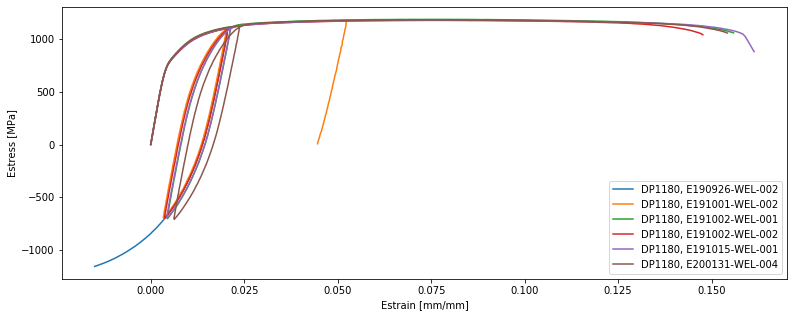

In [65]:
fig, ax = plt.subplots(figsize=[13,5])
for matname, df_mat in df_exp.groupby("Material"):
    if not matname.startswith("DP1180"):
        continue
        
    for expname, df in df_mat.groupby("Experiment"):
        print(expname)
        x_name = "Estrain"
        y_name = "Estress"
        ax.plot(df[x_name], df[y_name], label="{}, {}".format(matname, expname))

ax.legend()

x_attr = data.metadata.get(x_name)
y_attr = data.metadata.get(y_name)

ax.set_xlabel("{0.name} [{0.unit}]".format(x_attr))
ax.set_ylabel("{0.name} [{0.unit}]".format(y_attr))


Text(0, 0.5, 'Force [N]')

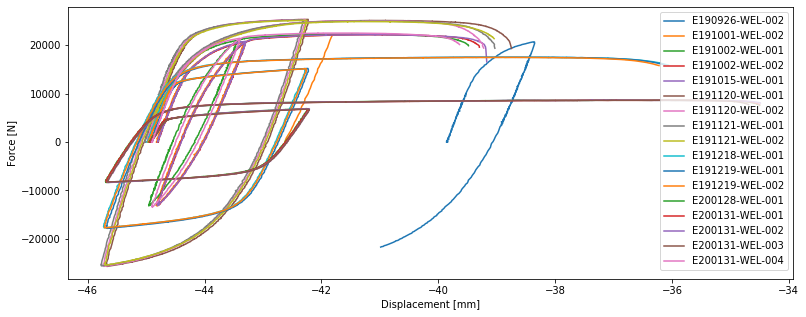

In [53]:
fig, ax = plt.subplots(figsize=[13,5])
for expname, df in df_exp.groupby("Experiment"):
    x_name = "Displacement"
    y_name = "Force"
    ax.plot(df[x_name], df[y_name], label=expname)

ax.legend()

x_attr = data.metadata.get(x_name)
y_attr = data.metadata.get(y_name)

ax.set_xlabel("{0.name} [{0.unit}]".format(x_attr))
ax.set_ylabel("{0.name} [{0.unit}]".format(y_attr))


DP1180 E191001-WEL-002
163


Text(0, 0.5, 'Estress [MPa]')

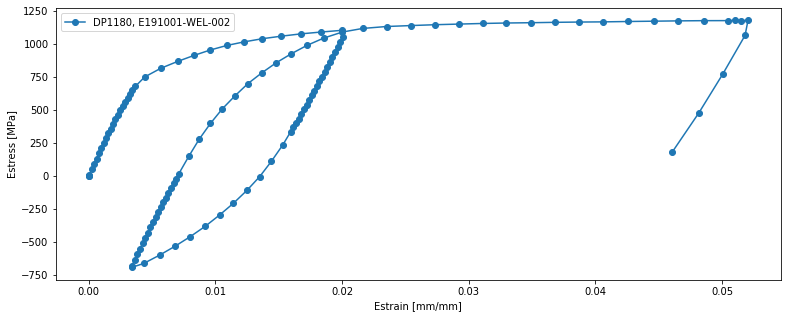

In [73]:
fig, ax = plt.subplots(figsize=[13,5])
for matname, df_mat in df_exp.groupby("Material"):
    for expname, df in df_mat.groupby("Experiment"):
        if expname!="E191001-WEL-002":
            continue
        print(matname, expname)
        x_name = "Estrain"
        y_name = "Estress"
        n = 10
        ax.plot(df[x_name][::n], df[y_name][::n], label="{}, {}".format(matname, expname), marker="o")

print(len(df[x_name][::n]))
ax.legend()

x_attr = data.metadata.get(x_name)
y_attr = data.metadata.get(y_name)

ax.set_xlabel("{0.name} [{0.unit}]".format(x_attr))
ax.set_ylabel("{0.name} [{0.unit}]".format(y_attr))


In [78]:
df.head(2)

,Time,Displacement,Force,Estress,Estrain,Tstress,Tstrain,Specimen,Material,Geometry,...,dedt,IntendedRate,StrainA,StrainfG,eyyA,eyyfgA,Path,ASPID,NumisheetID,dedtnomlabel
index,,,,,,,,,,,,,,,,,,,,,
10790,0.0000,-44.9600,-1.5,-0.059434,0.000000,-0.059434,0.000000,S191107-ERR-177,DP980,A36R19W18,...,NaN,0.00025,0.000000,0.000000,-3.431153e-18,-3.240499e-18,TCT,Lot #45: 1.40N CR700Y980T-DP-EGxxGxxG,C00FeDP980_Numisheet2020R03T1.409W17.91-S,0.00025 mm/mm/s
10791,0.3503,-44.9576,-3.5,-0.138680,-0.000008,-0.138679,-0.000008,S191107-ERR-177,DP980,A36R19W18,...,NaN,0.00025,-0.000008,-0.000008,1.210824e-06,2.222891e-06,TCT,Lot #45: 1.40N CR700Y980T-DP-EGxxGxxG,C00FeDP980_Numisheet2020R03T1.409W17.91-S,0.00025 mm/mm/s


In [80]:
import copy
data_dp980=copy.deepcopy(data)

In [81]:
data_dp980.df = df.copy()

In [83]:
data_dp980.metadata.df

,name,value,dtype,unit,description,label
key,,,,,,
sdata_version,sdata_version,0.8.3,str,-,,
Time,Time,None,float,s,Time,None
Displacement,Displacement,None,float,mm,Actuator displacement,None
Force,Force,None,float,N,Load washer force,None
Estress,Estress,None,float,MPa,Engineering stress,None
Estrain,Estrain,None,float,mm/mm,Engineering strain,None
Tstress,Tstress,None,float,MPa,True stress,None
Tstrain,Tstrain,None,float,mm/mm,True strain,None
EstrainRate,EstrainRate,None,float,mm/mm/s,Engineering strain rate computed from smooth s...,None


In [111]:
data_dp980.metadata.add("Material", df.iloc[0].Material)
data_dp980.metadata.add("Geometry", df.iloc[0].Geometry)
data_dp980.metadata.add("Specimen", df.iloc[0].Specimen)
data_dp980.metadata.add("Experiment", df.iloc[0].Experiment)
data_dp980.metadata.add("IntendedRate", df.iloc[0].IntendedRate)
data_dp980.metadata.add("NumisheetID", df.iloc[0].NumisheetID)
data_dp980.metadata.add("Path", df.iloc[0].Path)
data_dp980.metadata.add("ASPID", df.iloc[0].ASPID)
data_dp980.metadata.add("dedtnomlabel", df.iloc[0].dedtnomlabel.split()[0], dtype="float", unit="mm/mm/s")


In [112]:
data_dp980.metadata.df

,name,value,dtype,unit,description,label
key,,,,,,
sdata_version,sdata_version,0.8.3,str,-,,
Time,Time,None,float,s,Time,None
Displacement,Displacement,None,float,mm,Actuator displacement,None
Force,Force,None,float,N,Load washer force,None
Estress,Estress,None,float,MPa,Engineering stress,None
Estrain,Estrain,None,float,mm/mm,Engineering strain,None
Tstress,Tstress,None,float,MPa,True stress,None
Tstrain,Tstrain,None,float,mm/mm,True strain,None
EstrainRate,EstrainRate,None,float,mm/mm/s,Engineering strain rate computed from smooth s...,None


In [113]:
df.iloc[0]

Time                                                    0
Displacement                                       -44.96
Force                                                -1.5
Estress                                        -0.0594342
Estrain                                                 0
Tstress                                        -0.0594342
Tstrain                                                 0
Specimen                                  S191107-ERR-177
Material                                            DP980
Geometry                                        A36R19W18
Experiment                                E191121-WEL-002
dedt                                                  NaN
IntendedRate                                      0.00025
StrainA                                                 0
StrainfG                                                0
eyyA                                         -3.43115e-18
eyyfgA                                        -3.2405e-18
Path          

In [ ]:
data_dp980.to_xlsx(os.path.join(workpath, data_dp980.osname+".xlsx"))